In [1]:
import os
import nltk
import numpy as np

from typing import List, TypedDict, Optional

from dotenv import load_dotenv

from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.document_loaders import PyMuPDFLoader

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

from rank_bm25 import BM25Okapi

from sentence_transformers import SentenceTransformer, CrossEncoder

from langgraph.graph import StateGraph, END

from groq import Groq

In [2]:
nltk.download("punkt")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")

In [4]:
client = Groq(api_key=GROQ_API_KEY)

def llm(prompt):

    completion = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role":"user","content":prompt}],
        temperature=0.2
    )

    return completion.choices[0].message.content

In [5]:
embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-base-en-v1.5",
    model_kwargs={"device":"cpu"}
)

semantic_model = SentenceTransformer("all-MiniLM-L6-v2")

cross_encoder = CrossEncoder("BAAI/bge-reranker-base")

C:\Users\user\AppData\Local\Temp\ipykernel_22372\986535980.py:1: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(
c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when

In [6]:
def load_documents(path):

    loader = PyMuPDFLoader(path)

    docs = loader.load()

    return docs

In [7]:
def semantic_chunk(text, threshold=0.75):

    sentences = nltk.sent_tokenize(text)

    embeddings_sent = semantic_model.encode(sentences)

    chunks = []

    current_chunk = [sentences[0]]

    for i in range(1, len(sentences)):

        sim = np.dot(embeddings_sent[i], embeddings_sent[i-1]) / (
            np.linalg.norm(embeddings_sent[i]) *
            np.linalg.norm(embeddings_sent[i-1])
        )

        if sim < threshold:

            chunks.append(" ".join(current_chunk))

            current_chunk = []

        current_chunk.append(sentences[i])

    chunks.append(" ".join(current_chunk))

    return chunks

In [8]:
def adaptive_chunking(text):

    semantic_chunks = semantic_chunk(text)

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=500,
        chunk_overlap=100
    )

    final_chunks = []

    for chunk in semantic_chunks:

        splits = splitter.split_text(chunk)

        final_chunks.extend(splits)

    return final_chunks

In [9]:
def hierarchical_split(docs):

    parent_docs = []

    child_docs = []

    for doc in docs:

        parents = semantic_chunk(doc.page_content)

        for parent in parents:

            parent_docs.append(Document(page_content=parent))

            children = adaptive_chunking(parent)

            for child in children:

                child_docs.append(
                    Document(
                        page_content=child,
                        metadata={"parent": parent}
                    )
                )

    return parent_docs, child_docs

In [10]:
vector_store = None
bm25_index = None
bm25_corpus = None


def build_retriever(child_docs):

    global vector_store
    global bm25_index
    global bm25_corpus

    vector_store = Chroma.from_documents(
        documents=child_docs,
        embedding=embeddings,
        persist_directory="./chroma_db"
    )

    corpus = [doc.page_content for doc in child_docs]

    tokenized = [c.split() for c in corpus]

    bm25_corpus = corpus

    bm25_index = BM25Okapi(tokenized)

In [11]:
def hybrid_search(query, k=8):

    vector_docs = vector_store.similarity_search(query, k=k)

    tokenized_query = query.split()

    scores = bm25_index.get_scores(tokenized_query)

    top_idx = np.argsort(scores)[::-1][:k]

    bm25_docs = []

    for i in top_idx:

        bm25_docs.append(
            Document(page_content=bm25_corpus[i])
        )

    return vector_docs + bm25_docs

In [12]:
def rerank(query, docs, top_k=6):

    pairs = [(query, d.page_content) for d in docs]

    scores = cross_encoder.predict(pairs)

    ranked = sorted(
        zip(docs, scores),
        key=lambda x: x[1],
        reverse=True
    )

    return [doc for doc,_ in ranked[:top_k]]

In [13]:
def rewrite_query(query):

    prompt=f"""
Rewrite the legal query to improve retrieval.

Query:
{query}

Return only improved query.
"""

    return llm(prompt)

In [14]:
class LegalState(TypedDict):

    question: str

    rewritten_query: Optional[str]

    retrieved_docs: Optional[List]

    final_docs: Optional[List]

    answer: Optional[str]

    critique: Optional[str]

In [15]:
def rewrite_agent(state: LegalState):

    q = state["question"]

    new_query = rewrite_query(q)

    return {"rewritten_query": new_query}

In [16]:
def retrieval_agent(state: LegalState):

    query = state["rewritten_query"]

    docs = hybrid_search(query)

    return {"retrieved_docs": docs}

In [17]:
def fusion_agent(state: LegalState):

    query = state["rewritten_query"]

    docs = state["retrieved_docs"]

    final_docs = rerank(query, docs)

    return {"final_docs": final_docs}

In [18]:
def answer_agent(state: LegalState):

    docs = state["final_docs"]

    context = "\n\n".join([d.page_content for d in docs])

    prompt=f"""
Answer the legal question using the context.

Context:
{context}

Question:
{state['question']}
"""

    ans = llm(prompt)

    return {"answer": ans}

In [19]:
def critic_agent(state: LegalState):

    prompt=f"""
Evaluate the answer.

Question:
{state['question']}

Answer:
{state['answer']}

Is the answer correct and grounded in context?
Explain briefly.
"""

    critique = llm(prompt)

    return {"critique": critique}

In [20]:
workflow = StateGraph(LegalState)

workflow.add_node("rewrite", rewrite_agent)
workflow.add_node("retrieve", retrieval_agent)
workflow.add_node("fusion", fusion_agent)
workflow.add_node("answer", answer_agent)
workflow.add_node("critic", critic_agent)

workflow.set_entry_point("rewrite")

workflow.add_edge("rewrite", "retrieve")
workflow.add_edge("retrieve", "fusion")
workflow.add_edge("fusion", "answer")
workflow.add_edge("answer", "critic")

workflow.add_edge("critic", END)

graph = workflow.compile()

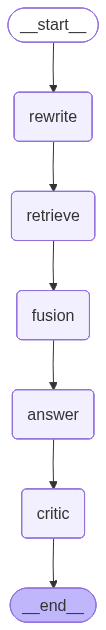

In [22]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
doc_path = r"C:/Users/user/Desktop/RAG Projects/Legal RAG 1/data/Mrs_Vandana_Dhirani_vs_Mrs_Arti_Kirloskar_on_27_July_2023.PDF"

docs = load_documents(doc_path)

parents, children = hierarchical_split(docs)

build_retriever(children)

In [24]:
query = "Who is the plaintiff in this case?"

result = graph.invoke({"question": query})

print("ANSWER:\n")
print(result["answer"])

print("\nCRITIQUE:\n")
print(result["critique"])

ANSWER:

According to the context, the plaintiff in this case is Mrs. Vandana Dhirani. This is mentioned in the line: "15 CS DJ NO.588/2021 Mrs. Vandana Dhirani Vs. Mrs. Arti Kirloskar". In a legal case, the format "Plaintiff Vs. Defendant" is typically used, so Mrs. Vandana Dhirani is the plaintiff and Mrs. Arti Kirloskar is the defendant.

CRITIQUE:

Yes, the answer is correct and grounded in context. The answer accurately identifies the plaintiff, Mrs. Vandana Dhirani, based on the standard legal case format "Plaintiff Vs. Defendant" and provides a specific reference to the context that supports this identification.
